# Project Title: Global Development & Socio-Economic Risk
#                 Segmentation Analysis

# 1.Data Understanding & Cleaning

# ● Load dataset

In [1]:
import pandas as pd

df = pd.read_csv(r"Country_data.csv")
print("Data has Loaded Successfully")
df.head()

Data has Loaded Successfully


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


# ● Check for missing values and duplicates.

In [2]:
df.info()
# Observed that there are no missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [3]:
df["country"].duplicated
# No duplicates found

<bound method Series.duplicated of 0              Afghanistan
1                  Albania
2                  Algeria
3                   Angola
4      Antigua and Barbuda
              ...         
162                Vanuatu
163              Venezuela
164                Vietnam
165                  Yemen
166                 Zambia
Name: country, Length: 167, dtype: object>

# ● Validating data types for all numeric columns

In [4]:
df.dtypes

country        object
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object

In [5]:
print("All the dtypes are valid")

All the dtypes are valid


Checking for null values using .isna()

In [6]:
df[['child_mort', 'exports', 'health', 'imports', 'inflation', 'life_expec', 'total_fer']].isna().sum()

child_mort    0
exports       0
health        0
imports       0
inflation     0
life_expec    0
total_fer     0
dtype: int64

In [7]:
print("No missing values detected in the dataset.")

No missing values detected in the dataset.


In [8]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


# ● Detecting and treating outliers (income, gdpp, child_mort, inflation) 

In [9]:
cols = ['income', 'gdpp', 'child_mort', 'inflation']

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

income: 8 outliers
gdpp: 25 outliers
child_mort: 4 outliers
inflation: 5 outliers


Checking skewness for columns (income, gdpp, child_mort, inflation)

In [10]:
df[['income', 'gdpp', 'child_mort', 'inflation']].skew()

income        2.231480
gdpp          2.218051
child_mort    1.450774
inflation     5.154049
dtype: float64

In [11]:
df[['income', 'gdpp', 'child_mort', 'inflation']].describe()

,income,gdpp,child_mort,inflation
count,167.000000,167.000000,167.000000,167.000000
mean,17144.688623,12964.155689,38.270060,7.781832
std,19278.067698,18328.704809,40.328931,10.570704
min,609.000000,231.000000,2.600000,-4.210000
25%,3355.000000,1330.000000,8.250000,1.810000
50%,9960.000000,4660.000000,19.300000,5.390000
75%,22800.000000,14050.000000,62.100000,10.750000
max,125000.000000,105000.000000,208.000000,104.000000


Using log for columns (income, gdpp)
"Log is used when data is positive + highly skewed + wide range”

In [12]:
import numpy as np

df['income'] = np.log1p(df['income'])
df['gdpp'] = np.log1p(df['gdpp'])
df['child_mort'] = np.log1p(df['child_mort'])

Using clip method for column (child_mort, inflation), "log method cannot be used column inflation because it is not applicable for negative values"

In [13]:
#df['child_mort'] = df['child_mort'].clip(lower, upper)
df['inflation'] = df['inflation'].clip(lower, upper)

In [14]:
df[['income', 'gdpp', 'child_mort', 'inflation']].describe()

,income,gdpp,child_mort,inflation
count,167.000000,167.000000,167.000000,167.000000
mean,9.115631,8.500171,3.127734,7.065066
std,1.228722,1.499398,1.087226,6.704968
min,6.413459,5.446737,1.280934,-4.210000
25%,8.118495,7.193573,2.223907,1.810000
50%,9.206433,8.446985,3.010621,5.390000
75%,10.034550,9.549682,4.144720,10.750000
max,11.736077,11.561725,5.342334,24.160000


# ● Handling negative or extreme inflation values.

In [15]:
low_inf = df['inflation'].quantile(0.01)
up_inf = df['inflation'].quantile(0.99)

df['inflation'] = df['inflation'].clip(low_inf, up_inf)
df['inflation'].describe()

count    167.000000
mean       7.081428
std        6.679894
min       -2.348800
25%        1.810000
50%        5.390000
75%       10.750000
max       24.160000
Name: inflation, dtype: float64

# ● Performing consistency checks

In [16]:
(df[['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']]<0).sum()

child_mort    0
exports       0
health        0
imports       0
income        0
inflation     8
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [17]:
df['inflation'].sort_values().head(10)

73    -2.3488
131   -2.3488
77    -1.9000
43    -1.4300
135   -0.9870
85    -0.8120
10    -0.3930
133   -0.0460
139    0.1600
86     0.2380
Name: inflation, dtype: float64

In [18]:
print("Negative inflation values represent deflation and are considered valid; no adjustments are required.")

Negative inflation values represent deflation and are considered valid; no adjustments are required.


In [19]:
df['child_mort'].value_counts()

child_mort
1.704748    4
4.718499    3
3.222868    3
1.648659    3
1.435085    3
           ..
3.407842    1
2.895912    1
3.190476    1
4.048301    1
4.432007    1
Name: count, Length: 139, dtype: int64

In [20]:
high_income_deflation = df[(df['inflation'] < 0) & (df['income'] > df['income'].median())]
print(high_income_deflation[['country', 'income', 'inflation']])

            country     income  inflation
10          Bahamas  10.038936    -0.3930
43   Czech Republic  10.250652    -1.4300
73          Ireland  10.729875    -2.3488
77            Japan  10.485731    -1.9000
85           Latvia   9.814711    -0.8120
131      Seychelles   9.923339    -2.3488
133       Singapore  11.185823    -0.0460
135        Slovenia  10.264687    -0.9870


In [21]:
high_income_deflation[['life_expec', 'child_mort']].describe()

,life_expec,child_mort
count,8.000000,8.000000
mean,77.900000,1.867397
std,4.072907,0.583625
min,73.100000,1.335001
25%,73.700000,1.435085
50%,78.500000,1.565132
75%,80.975000,2.304721
max,82.800000,2.734368


In [22]:
print("Subset of high-income countries experiencing deflation extracted; no inconsistencies observed in key indicators.")

Subset of high-income countries experiencing deflation extracted; no inconsistencies observed in key indicators.


In [23]:
low_income_inflation = df[(df['inflation']>0) & (df['income'] < df['income'].median())]
print(low_income_inflation[['country', 'income', 'inflation']])

         country    income  inflation
0    Afghanistan  7.384610       9.44
1        Albania  9.203416       4.49
3         Angola  8.682877      22.40
6        Armenia  8.810012       7.77
12    Bangladesh  7.800163       7.14
..           ...       ...        ...
161   Uzbekistan  8.352554      16.50
162      Vanuatu  7.989899       2.62
164      Vietnam  8.409831      12.10
165        Yemen  8.407602      23.60
166       Zambia  8.095904      14.00

[83 rows x 3 columns]


In [24]:
low_income_inflation[['life_expec', 'child_mort']].describe()

,life_expec,child_mort
count,83.000000,83.000000
mean,64.707229,3.936139
std,7.884344,0.724672
min,32.100000,2.066863
25%,59.400000,3.342462
50%,65.500000,4.091006
75%,70.800000,4.515245
max,76.800000,5.342334


In [25]:
print("Subset of low-income countries experiencing inflation extracted; no inconsistencies observed in key indicators.")

Subset of low-income countries experiencing inflation extracted; no inconsistencies observed in key indicators.


# Derived Features

# ● Development_Index

Checking for '0' values to avoid ZeroDivisionError

In [26]:
print((df['child_mort'] == 0).any())

False


Creating new column ('Development_Index')

In [27]:
df['Development_Index'] = (df['income'] + df['gdpp'] + df['life_expec']) / df['child_mort']

In [28]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Development_Index
0,Afghanistan,4.513055,10.0,7.58,44.9,7.384610,9.44,56.2,5.82,6.317165,15.488793
1,Albania,2.867899,28.0,6.55,48.6,9.203416,4.49,76.3,1.65,8.316545,32.713831
2,Algeria,3.342862,38.4,4.17,31.4,9.465060,16.10,76.5,2.89,8.403128,28.229761
3,Angola,4.787492,62.3,2.85,42.9,8.682877,22.40,60.1,6.16,8.169336,16.073597
4,Antigua and Barbuda,2.424803,45.5,6.03,58.9,9.857496,1.44,76.8,2.13,9.409273,39.618386


In [29]:
print((df['Development_Index'] == 0).any())

False


In [30]:
print(df['Development_Index'].skew())

0.884825750185395


# ● Trade_Balance 

Creating new column ('Trade_Balance')

In [31]:
df['Trade_Balance'] = df['exports'] - df['imports']

In [32]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Development_Index,Trade_Balance
0,Afghanistan,4.513055,10.0,7.58,44.9,7.384610,9.44,56.2,5.82,6.317165,15.488793,-34.9
1,Albania,2.867899,28.0,6.55,48.6,9.203416,4.49,76.3,1.65,8.316545,32.713831,-20.6
2,Algeria,3.342862,38.4,4.17,31.4,9.465060,16.10,76.5,2.89,8.403128,28.229761,7.0
3,Angola,4.787492,62.3,2.85,42.9,8.682877,22.40,60.1,6.16,8.169336,16.073597,19.4
4,Antigua and Barbuda,2.424803,45.5,6.03,58.9,9.857496,1.44,76.8,2.13,9.409273,39.618386,-13.4


In [33]:
df['Trade_Balance'].describe()

count    167.000000
mean      -5.781239
std       18.942578
min      -73.500000
25%      -14.850000
50%       -4.800000
75%        3.850000
max       39.400000
Name: Trade_Balance, dtype: float64

In [34]:
print((df['Trade_Balance'] == 0).any())

False


# ● Health_Impact_Ratio

Creating a new column ('Health_Impact_Ratio')

In [35]:
df['Health_Impact_Ratio'] = df['health'] / df['child_mort']
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Development_Index,Trade_Balance,Health_Impact_Ratio
0,Afghanistan,4.513055,10.0,7.58,44.9,7.384610,9.44,56.2,5.82,6.317165,15.488793,-34.9,1.679572
1,Albania,2.867899,28.0,6.55,48.6,9.203416,4.49,76.3,1.65,8.316545,32.713831,-20.6,2.283902
2,Algeria,3.342862,38.4,4.17,31.4,9.465060,16.10,76.5,2.89,8.403128,28.229761,7.0,1.247434
3,Angola,4.787492,62.3,2.85,42.9,8.682877,22.40,60.1,6.16,8.169336,16.073597,19.4,0.595301
4,Antigua and Barbuda,2.424803,45.5,6.03,58.9,9.857496,1.44,76.8,2.13,9.409273,39.618386,-13.4,2.486800


In [36]:
df['Health_Impact_Ratio'].describe()

count    167.000000
mean       2.671301
std        1.868480
min        0.471233
25%        1.347616
50%        2.085594
75%        3.516040
max        8.458336
Name: Health_Impact_Ratio, dtype: float64

# Risk_Flag 

In [37]:
cm_high = df['child_mort'].quantile(0.75)
le_low  = df['life_expec'].quantile(0.25)
inc_low = df['income'].quantile(0.25)

score = (
    (df['child_mort'] > cm_high).astype(int) +
    (df['life_expec'] < le_low).astype(int) +
    (df['income'] < inc_low).astype(int)
)
df['Segment'] = score.map(lambda x: 'High' if x >= 2 else ('Medium' if x == 1 else 'Low'))

In [38]:
df = df.rename(columns={
    'Segment': 'Risk_Flag'
})

In [39]:
df.head(1)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Development_Index,Trade_Balance,Health_Impact_Ratio,Risk_Flag
0,Afghanistan,4.513055,10.0,7.58,44.9,7.38461,9.44,56.2,5.82,6.317165,15.488793,-34.9,1.679572,High


# 2. Exploratory Data Analysis 

# Univariate Analysis

# ● Distribution of income

In [40]:
df['income'].describe()

count    167.000000
mean       9.115631
std        1.228722
min        6.413459
25%        8.118495
50%        9.206433
75%       10.034550
max       11.736077
Name: income, dtype: float64

In [41]:
df['income'].skew()

np.float64(-0.23582308003947594)

In [42]:
iqr = df['income'].quantile(0.75)-df['income'].quantile(0.25)
range = df['income'].max()-df['income'].min()
print(f"iqr = {iqr}")
print(f"range = {range}")

iqr = 1.9160549772414956
range = 5.32261805908508


In [43]:
import seaborn as sns

Using histogram to see spread, skewness, peaks

<Axes: xlabel='income', ylabel='Count'>

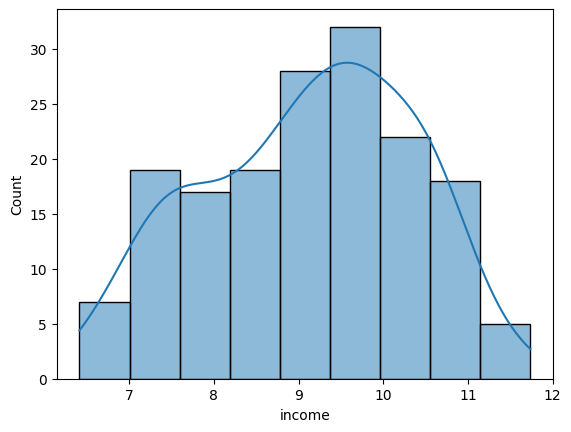

In [44]:
sns.histplot(data=df, x='income', kde=True)

Using Boxplot to detect Outliners

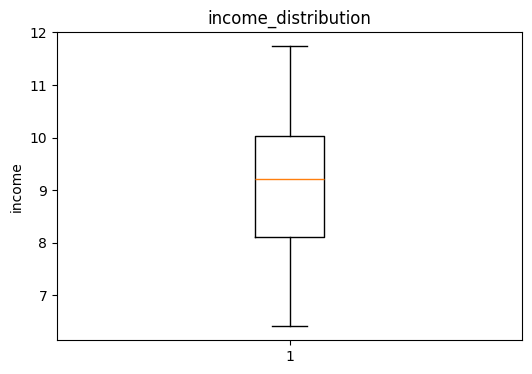

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.boxplot(df['income'])
plt.title("income_distribution")
plt.ylabel("income")
plt.show()


In [46]:
print("Income is approximately symmetric with slight negative skew and no significant outliers; hence, no transformation is required.")

Income is approximately symmetric with slight negative skew and no significant outliers; hence, no transformation is required.


# ● Distribution of child mortality

In [47]:
df['child_mort'].describe()

count    167.000000
mean       3.127734
std        1.087226
min        1.280934
25%        2.223907
50%        3.010621
75%        4.144720
max        5.342334
Name: child_mort, dtype: float64

In [48]:
df['child_mort'].skew()

np.float64(0.06615993685980348)

In [49]:
iqr = df['child_mort'].quantile(0.75)-df['child_mort'].quantile(0.25)
range = df['child_mort'].max()-df['child_mort'].min()
print(f"iqr = {iqr}")
print(f"range = {range}")

iqr = 1.9208123261662293
range = 4.061400406502747


Using histogram to see spread, skewness, peaks

<Axes: xlabel='child_mort', ylabel='Count'>

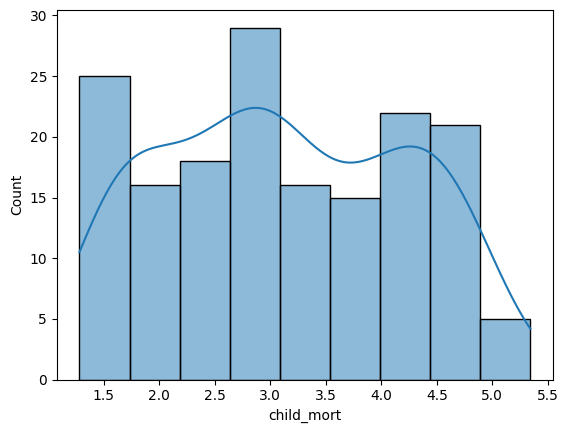

In [50]:
import seaborn as sns
sns.histplot(data=df, x='child_mort', kde=True)

Using Boxplot to detect Outliners

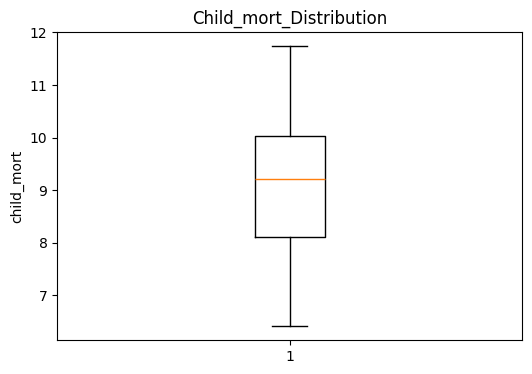

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.boxplot(df['income'])
plt.title("Child_mort_Distribution")
plt.ylabel("child_mort")
plt.show()

In [52]:
print("The child_mort variable has been fully validated through univariate analysis and requires no transformation or outlier treatment.")

The child_mort variable has been fully validated through univariate analysis and requires no transformation or outlier treatment.


# ● Distribution of life expectancy

In [53]:
df['life_expec'].describe()

count    167.000000
mean      70.555689
std        8.893172
min       32.100000
25%       65.300000
50%       73.100000
75%       76.800000
max       82.800000
Name: life_expec, dtype: float64

In [54]:
df['life_expec'].skew()

np.float64(-0.9709955819991258)

In [55]:
iqr = df['life_expec'].quantile(0.75)-df['life_expec'].quantile(0.25)
range = df['life_expec'].max()-df['life_expec'].min()
print(f"iqr = {iqr}")
print(f"range = {range}")

iqr = 11.5
range = 50.699999999999996


Using histogram to see spread, skewness, peaks

<Axes: xlabel='life_expec', ylabel='Count'>

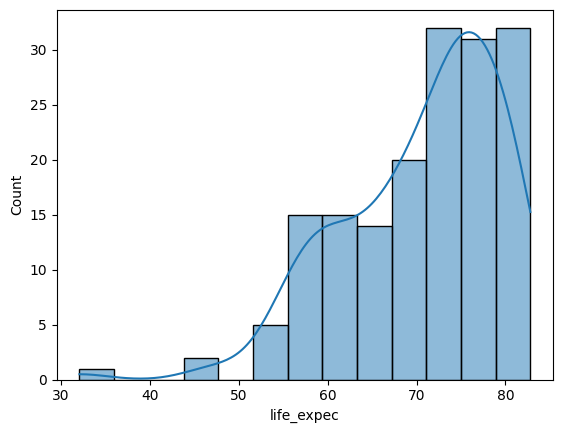

In [56]:
import seaborn as sns
sns.histplot(data=df, x='life_expec', kde=True)

Using Boxplot to detect Outliners

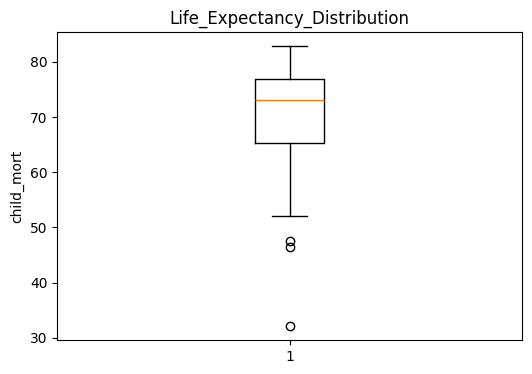

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.boxplot(df['life_expec'])
plt.title("Life_Expectancy_Distribution")
plt.ylabel("child_mort")
plt.show()

NOTE: 
No preprocessing is required for life_expec. The observed skewness and outliers reflect real-world variation and are retained to preserve the integrity and interpretability of the data.

# ● Fertility rate analysis

In [58]:
df['total_fer'].describe()

count    167.000000
mean       2.947964
std        1.513848
min        1.150000
25%        1.795000
50%        2.410000
75%        3.880000
max        7.490000
Name: total_fer, dtype: float64

In [59]:
df['total_fer'].skew()

np.float64(0.9670916808050207)

In [60]:
iqr = df['total_fer'].quantile(0.75)-df['total_fer'].quantile(0.25)
range = df['total_fer'].max()-df['total_fer'].min()
print(f"iqr = {iqr}")
print(f"range = {range}")

iqr = 2.085
range = 6.34


<Axes: xlabel='total_fer', ylabel='Count'>

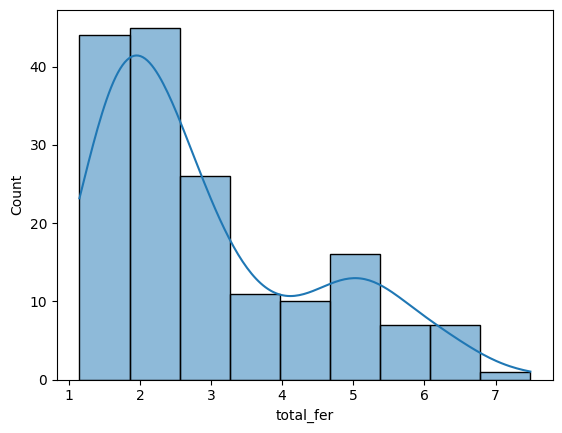

In [61]:
import seaborn as sns
sns.histplot(data=df, x='total_fer', kde=True)

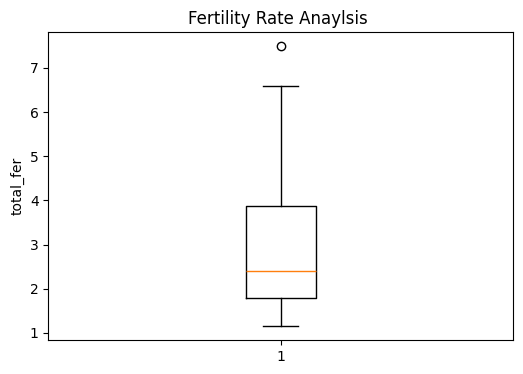

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.boxplot(df['total_fer'])
plt.title("Fertility Rate Anaylsis ")
plt.ylabel("total_fer")
plt.show()

NOTE : The total fertility rate shows a moderately right-skewed distribution (skew ≈ 0.97) with higher-end values, all of which are realistic; hence, no outlier treatment or transformation is required.


# Bivariate / Multivariate Analysis

# ● Income vs Life Expectancy

In [63]:
df['income_e'] = pd.qcut(df['income'], q=3, labels=['Low', 'Medium', 'High'])

"For each income group, finding the 25%, 50%, 75% values of life ecpectancy"

In [64]:
df.groupby('income_e', observed=True)['life_expec'].quantile([0.25,0.50,0.75])

income_e      
Low       0.25    57.650
          0.50    61.750
          0.75    66.425
Medium    0.25    70.350
          0.50    73.900
          0.75    76.350
High      0.25    76.000
          0.50    79.500
          0.75    80.750
Name: life_expec, dtype: float64

<Axes: xlabel='income_e', ylabel='life_expec'>

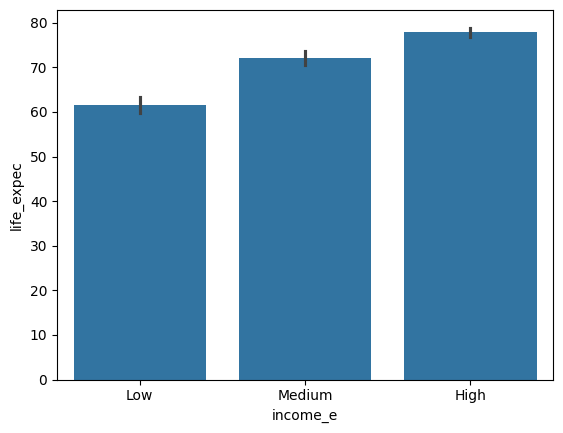

In [65]:
import seaborn as sns
sns.barplot(x='income_e', y='life_expec', data=df)

<Axes: xlabel='income_e', ylabel='life_expec'>

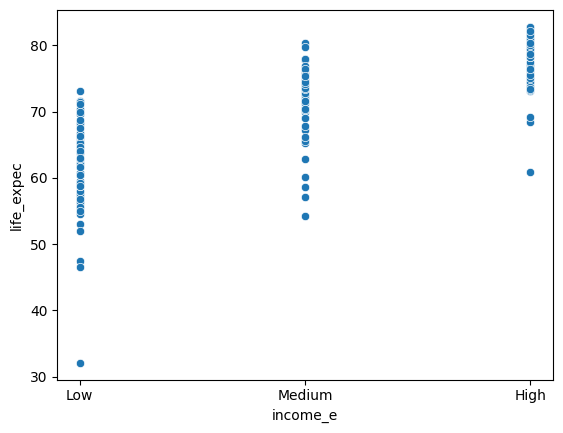

In [66]:
import seaborn as sns 
sns.scatterplot(x='income_e', y='life_expec', data=df)


NOTE : Life expectancy increases with income, showing a positive relationship with an upward shift in distribution and minor overlap between groups.

In [67]:
df = df.drop(columns=[
    'income_e'
], errors='ignore')

# ● Health Expenditure vs Child Mortality

In [68]:
df['health_group'] = pd.qcut(df['health'], q=3, labels=['Low', 'Medium', 'High'])

In [69]:
df.groupby('health_group', observed=True)['child_mort'].quantile([0.25, 0.5, 0.75])

health_group      
Low           0.25    2.854776
              0.50    3.514309
              0.75    4.230586
Medium        0.25    2.450856
              0.50    3.190476
              0.75    4.010431
High          0.25    1.648659
              0.50    2.134009
              0.75    3.436791
Name: child_mort, dtype: float64

<Axes: xlabel='health_group', ylabel='child_mort'>

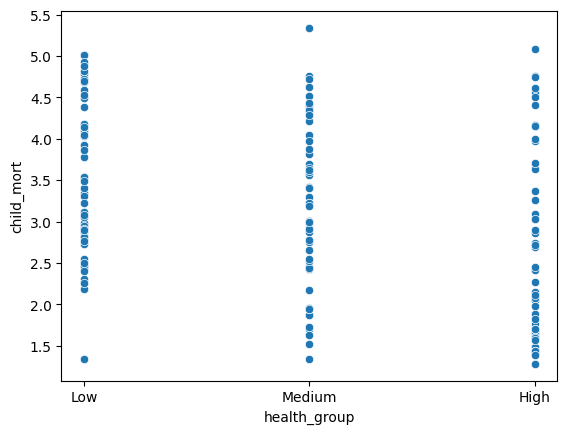

In [70]:
import seaborn as sns 
sns.scatterplot(x='health_group', y='child_mort', data=df)

NOTE: Child mortality decreases as health improves, indicating a negative relationship with a positive public health outcome, although some overlap between groups suggests the relationship is moderate rather than perfect.


In [71]:
df = df.drop(columns=[
    'health_group'
], errors='ignore')

# ● GDP vs Fertility Rate

In [72]:
df['gdp_p'] = pd.qcut(df['gdpp'], q=3, labels=['Low', 'Medium', 'High'])

In [73]:
df.groupby('gdp_p', observed=True)['total_fer'].quantile([0.25, 0.50, 0.75])

gdp_p       
Low     0.25    3.1825
        0.50    4.7100
        0.75    5.3450
Medium  0.25    1.7650
        0.50    2.4800
        0.75    2.7800
High    0.25    1.4750
        0.50    1.8500
        0.75    2.0725
Name: total_fer, dtype: float64

<Axes: xlabel='gdp_p', ylabel='total_fer'>

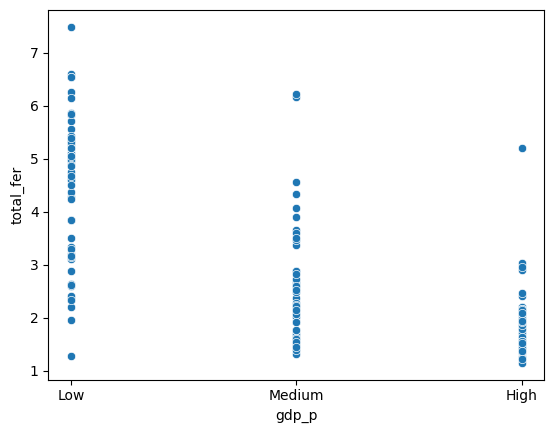

In [74]:
import seaborn as sns
sns.scatterplot(x='gdp_p', y='total_fer', data=df)

NOTE : An inverse relationship exists between GDP and fertility, where higher economic development leads to lower fertility due to improvements in education, urbanization, and access to family planning.


In [75]:
df = df.drop(columns=[
    'gdp_p'
], errors='ignore')

# ● Inflation vs GDP

In [76]:
df['inflation_n'] = pd.qcut(df['inflation'], q=3, labels=['Low', 'Medium', 'High']) 

In [77]:
df.groupby('inflation_n', observed=True)['gdpp'].quantile([0.25, 0.50, 0.75])

inflation_n      
Low          0.25     8.392941
             0.50     9.460988
             0.75    10.506492
Medium       0.25     7.135299
             0.50     8.425297
             0.75     9.068485
High         0.25     7.016730
             0.50     7.899385
             0.75     8.763355
Name: gdpp, dtype: float64

<Axes: xlabel='inflation_n', ylabel='gdpp'>

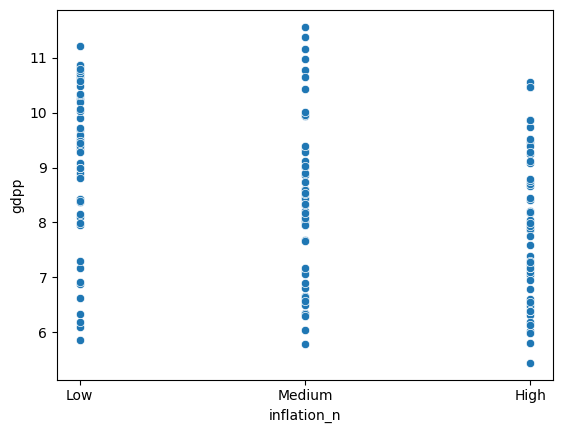

In [78]:
import seaborn as sns
sns.scatterplot(x='inflation_n', y='gdpp', data=df)

NOTE : “GDP shows a decreasing trend across inflation levels, indicating a negative association where higher inflation corresponds to lower economic output.”

In [79]:
df = df.drop(columns=[
    'inflation_n'
], errors='ignore')

# ● Trade Balance vs Income

In [80]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Development_Index,Trade_Balance,Health_Impact_Ratio,Risk_Flag
0,Afghanistan,4.513055,10.0,7.58,44.9,7.384610,9.44,56.2,5.82,6.317165,15.488793,-34.9,1.679572,High
1,Albania,2.867899,28.0,6.55,48.6,9.203416,4.49,76.3,1.65,8.316545,32.713831,-20.6,2.283902,Low
2,Algeria,3.342862,38.4,4.17,31.4,9.465060,16.10,76.5,2.89,8.403128,28.229761,7.0,1.247434,Low
3,Angola,4.787492,62.3,2.85,42.9,8.682877,22.40,60.1,6.16,8.169336,16.073597,19.4,0.595301,High
4,Antigua and Barbuda,2.424803,45.5,6.03,58.9,9.857496,1.44,76.8,2.13,9.409273,39.618386,-13.4,2.486800,Low


In [81]:
df['trade_bal'] = pd.qcut(df['Trade_Balance'], q=3 , labels=['Low', 'Medium', 'High'])

In [82]:
df.groupby('trade_bal', observed=True)['income'].quantile([0.25, 0.50, 0.75])

trade_bal      
Low        0.25     7.300194
           0.50     7.875286
           0.75     9.001297
Medium     0.25     8.520266
           0.50     9.392745
           0.75    10.014323
High       0.25     9.401883
           0.50    10.038898
           0.75    10.668393
Name: income, dtype: float64

<Axes: xlabel='trade_bal', ylabel='income'>

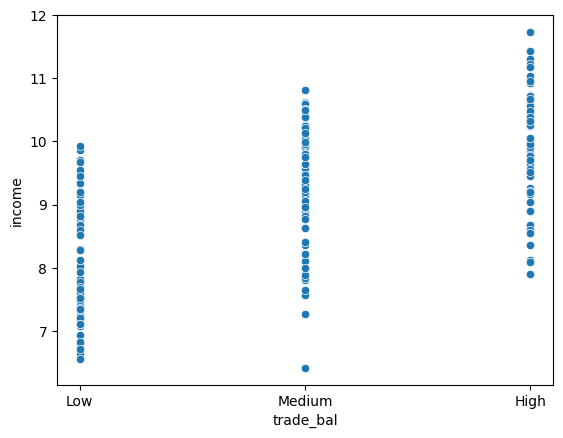

In [83]:
import seaborn as sns
sns.scatterplot(x='trade_bal', y='income', data=df)

NOTE : “Income increases consistently across trade balance categories, indicating a strong positive relationship with slight overlap between groups.”

In [84]:
df = df.drop(columns=[
    'trade_bal'
], errors='ignore')

# Correlation Analysis

# ● Correlation heatmap

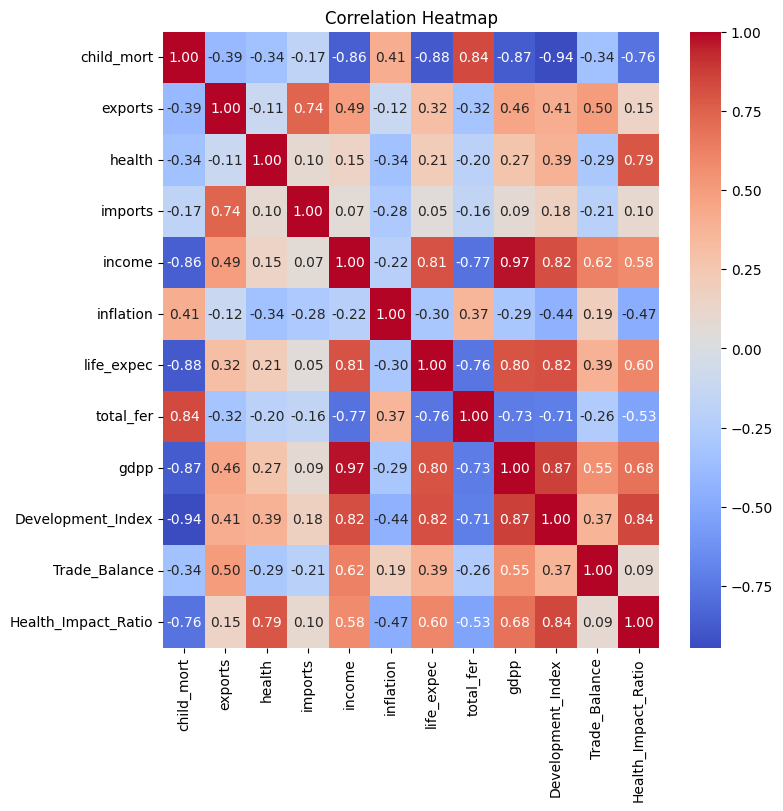

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_hm = df.corr(numeric_only=True)
plt.figure(figsize=(8,8))
sns.heatmap(corr_hm, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# ● Identifing strongest predictors of life expectancy and mortality.

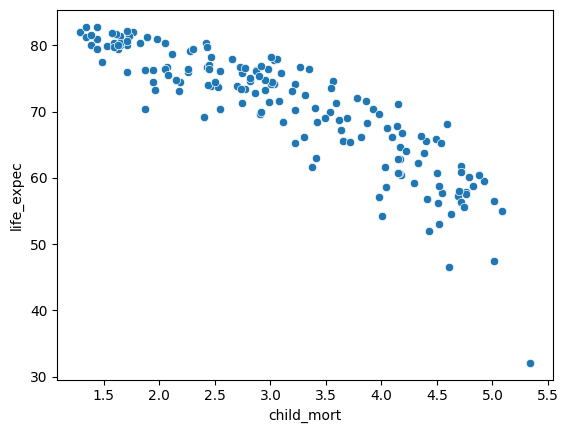

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='child_mort', y='life_expec', data=df)
plt.show()

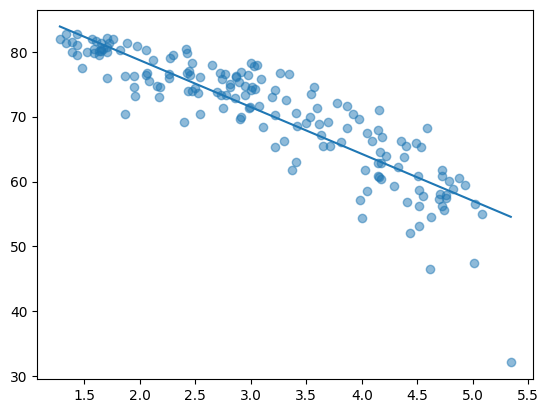

In [87]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

x = df['child_mort'].values
y = df['life_expec'].values
m, c = np.polyfit(x,y,1)
range = np.linspace(x.min(), x.max(), 100)
linear = m * range + c

plt.scatter(x,y,alpha=0.5)
plt.plot(range, linear, label='linear')

NOTE : “There is a strong negative linear relationship between child mortality and life expectancy, where increasing child mortality leads to a decrease in life expectancy."

Life expectancy is predicted using a linear regression model derived from NumPy’s polyfit function. The relationship between child mortality (independent variable) and life expectancy (dependent variable) is modeled as a linear equation

# 3.Rule-Based Country Segmentation (Python & SQL)

# ● Implementing segmentation in Python using conditional logic

Loading and Standardizing Columns

In [88]:
import pandas as pd
import numpy as np

# Load raw data
df = pd.read_csv("Country_data.csv")

# Standardize column names ONCE
df.columns = df.columns.str.strip().str.lower()

# Verify
print("Columns after cleaning:")
print(df.columns.tolist())

Columns after cleaning:
['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


# Creating Segmentation 

In [89]:
conditions = [
    (df['child_mort'] > 80) & (df['income'] < 5000),
    (df['health'] < 5) & (df['child_mort'] > 70),
    (df['inflation'] > 15),
    (df['income'] > 30000) & (df['life_expec'] > 78),
    (df['income'].between(8000, 30000)),
    (df['gdpp'] < 2000)
]

segment_name = [
    "High Risk Country", 
    "Health Critical",
    "High Inflation Risk",
    "Developed Nation", 
    "Emerging Economy",
    "Low GDP Trap"
]

df['segment'] = np.select(conditions, segment_name, default="Unclassified")

print(df['segment'].value_counts())

segment
Emerging Economy       54
High Risk Country      26
Developed Nation       26
High Inflation Risk    22
Unclassified           19
Low GDP Trap           17
Health Critical         3
Name: count, dtype: int64


Saving a Clean File

In [90]:
df.to_csv("country_clean.csv", index=False)
print("Clean file saved!")

Clean file saved!


Reloading Clean Data

In [91]:
df = pd.read_csv("country_clean.csv")

# Re-standardize just in case
df.columns = df.columns.str.strip().str.lower()

print(df.columns.tolist())

['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp', 'segment']


Selecting Columns in Correct Order

In [92]:
df_db = df[[
    'country',
    'child_mort',
    'exports',
    'health',
    'imports',
    'income',
    'inflation',
    'life_expec',
    'total_fer',
    'gdpp',
    'segment'
]]

print(df_db.head())

               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp              segment  
0       9.44        56.2       5.82    553    High Risk Country  
1       4.49        76.3       1.65   4090     Emerging Economy  
2      16.10        76.5       2.89   4460  High Inflation Risk  
3      22.40        60.1       6.16   3530      Health Critical  
4       1.44        76.8       2.13  12200     Emerging Economy  


# ● Generate segment-wise KPI summaries.

In [93]:
df_summary = df.groupby('segment', as_index=False).agg(
    avg_income=('income', 'mean'),
    avg_life=('life_expec', 'mean'),
    avg_child_mort=('child_mort', 'mean'),
    avg_inflation=('inflation','mean'),
    avg_health=('health','mean'),
    avg_gdpp=('gdpp','mean'),
    count=('country','count')   # better than income
).round(3)

print(df_summary)

               segment  avg_income  avg_life  avg_child_mort  avg_inflation  \
0     Developed Nation   48803.846    80.792           4.596          2.098   
1     Emerging Economy   16700.741    74.485          16.493          4.100   
2      Health Critical   14526.667    61.600         102.967         18.833   
3  High Inflation Risk   16146.818    69.773          39.173         24.364   
4    High Risk Country    1696.654    56.731         111.104          7.988   
5         Low GDP Trap    2718.824    65.741          50.518          7.369   
6         Unclassified   10698.947    70.926          24.358          5.166   

   avg_health   avg_gdpp  count  
0       9.306  49150.000     26  
1       7.057  10395.000     54  
2       3.933   7256.667      3  
3       4.996   7288.727     22  
4       6.712    697.115     26  
5       6.115   1019.235     17  
6       6.053   5695.263     19  


# 4.SQL Data Modeling & Queries

In [94]:
%pip install mysql-connector-python

Note: you may need to restart the kernel to use updated packages.


# Database Creation (SQL)

In [95]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="sakiley"
)

if conn.is_connected():
    print("Connection Successful!")  

cursor = conn.cursor() 
cursor.execute("CREATE DATABASE IF NOT EXISTS country_analysis")

cursor.close()
conn.close()  

Connection Successful!


# Connecting to MySQL and Creating Table

In [96]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="sakiley",
    database="country_analysis"
)

cursor = conn.cursor()

cursor.execute("DROP TABLE IF EXISTS country_stats")

cursor.execute("""
CREATE TABLE country_stats(
    country VARCHAR(100) PRIMARY KEY,
    child_mort FLOAT,
    exports FLOAT,
    health FLOAT,
    imports FLOAT,
    income FLOAT,
    inflation FLOAT,
    life_expec FLOAT,
    total_fer FLOAT,
    gdpp FLOAT,
    segment VARCHAR(50)
)
""")

conn.commit()
print("Table created!")

Table created!


In [97]:
cursor.execute("DESCRIBE country_stats")

for row in cursor.fetchall():
    print(row)

('country', 'varchar(100)', 'NO', 'PRI', None, '')
('child_mort', 'float', 'YES', '', None, '')
('exports', 'float', 'YES', '', None, '')
('health', 'float', 'YES', '', None, '')
('imports', 'float', 'YES', '', None, '')
('income', 'float', 'YES', '', None, '')
('inflation', 'float', 'YES', '', None, '')
('life_expec', 'float', 'YES', '', None, '')
('total_fer', 'float', 'YES', '', None, '')
('gdpp', 'float', 'YES', '', None, '')
('segment', 'varchar(50)', 'YES', '', None, '')


# Importing Cleaned Data into SQL Table 

In [98]:
# Convert dataframe to list of tuples

import pandas as pd
import mysql.connector

# Load CSV
df = pd.read_csv("Country_clean.csv")

# Check data
print(df.head())

# Connect to MySQL
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="sakiley",
    database="country_analysis"
)

cursor = conn.cursor()

# Converting to tuples (FIXED: using df_db, not df)
data = list(df.itertuples(index=False, name=None))

# Insert query
query = """
INSERT INTO country_stats(
    country,
    child_mort,
    exports,
    health,
    imports,
    income,
    inflation,
    life_expec,
    total_fer,
    gdpp,
    segment
)
VALUES(%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
"""

# Execute
cursor.executemany(query, data)
conn.commit()

print("Data inserted successfully!")

               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp              segment  
0       9.44        56.2       5.82    553    High Risk Country  
1       4.49        76.3       1.65   4090     Emerging Economy  
2      16.10        76.5       2.89   4460  High Inflation Risk  
3      22.40        60.1       6.16   3530      Health Critical  
4       1.44        76.8       2.13  12200     Emerging Economy  
Data inserted successfully!


# ● Implement same logic in SQL using CASE statements.

In [99]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="sakiley",
    database="country_analysis"
)  

cursor = conn.cursor()

import pandas as pd

df = pd.read_sql_query("""
                       
SELECT*,
CASE
    WHEN child_mort > 80 AND income < 5000 THEN 'High Risk Country'
    WHEN income > 30000 AND life_expec > 78 THEN 'Developed Nation'
    WHEN income between 8000 and 30000 THEN 'Emerging Economy'
    WHEN inflation > 15 THEN 'High Inflation Risk'
    WHEN health < 5 AND child_mort > 70 THEN 'Health Critical'
    WHEN gdpp < 2000 THEN 'Low GDP Trap'
    ELSE 'Unclassified'                   
END AS segment
FROM country_stats
                       
""", conn)
print(df)

                 country  child_mort  exports  health  imports   income  \
0            Afghanistan        90.2     10.0    7.58     44.9   1610.0   
1                Albania        16.6     28.0    6.55     48.6   9930.0   
2                Algeria        27.3     38.4    4.17     31.4  12900.0   
3                 Angola       119.0     62.3    2.85     42.9   5900.0   
4    Antigua and Barbuda        10.3     45.5    6.03     58.9  19100.0   
..                   ...         ...      ...     ...      ...      ...   
162              Vanuatu        29.2     46.6    5.25     52.7   2950.0   
163            Venezuela        17.1     28.5    4.91     17.6  16500.0   
164              Vietnam        23.3     72.0    6.84     80.2   4490.0   
165                Yemen        56.3     30.0    5.18     34.4   4480.0   
166               Zambia        83.1     37.0    5.89     30.9   3280.0   

     inflation  life_expec  total_fer     gdpp              segment  \
0         9.44        56.2  

C:\Users\Niharika\AppData\Local\Temp\ipykernel_10132\2995763159.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query("""


# Analytical Queries

● Average income per segment.

In [100]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="sakiley",
    database="country_analysis"
)  

cursor = conn.cursor()

import pandas as pd

df = pd.read_sql_query("""
SELECT
    segment,
    AVG(income) as avg_inc_per_seg
FROM country_stats
GROUP BY segment
ORDER BY avg_inc_per_seg DESC;                 
""", conn)

print(df)

               segment  avg_inc_per_seg
0     Developed Nation     48803.846154
1     Emerging Economy     16700.740741
2  High Inflation Risk     16146.818182
3      Health Critical     14526.666667
4         Unclassified     10698.947368
5         Low GDP Trap      2718.823529
6    High Risk Country      1696.653846


C:\Users\Niharika\AppData\Local\Temp\ipykernel_10132\1241122544.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query("""


● Top 10 high-risk countries.

In [101]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="sakiley",
    database="country_analysis"
)  

cursor = conn.cursor()

import pandas as pd

df = pd.read_sql_query("""
SELECT 
    country,
    child_mort,
    life_expec,
    CASE
        WHEN child_mort > 80 OR life_expec < 60 THEN 'High'
        WHEN child_mort > 40 THEN 'Medium'
        ELSE 'Low'
    END AS risk_flag
FROM country_stats
ORDER BY child_mort DESC
LIMIT 10;                  
""", conn)

print(df)

                    country  child_mort  life_expec risk_flag
0                     Haiti       208.0        32.1      High
1              Sierra Leone       160.0        55.0      High
2                      Chad       150.0        56.5      High
3  Central African Republic       149.0        47.5      High
4                      Mali       137.0        59.5      High
5                   Nigeria       130.0        60.5      High
6                     Niger       123.0        58.8      High
7                    Angola       119.0        60.1      High
8              Burkina Faso       116.0        57.9      High
9          Congo, Dem. Rep.       116.0        57.5      High


C:\Users\Niharika\AppData\Local\Temp\ipykernel_10132\1742109441.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query("""


● Countries with highest inflation.

In [102]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="sakiley",
    database="country_analysis"
)  

cursor = conn.cursor()

import pandas as pd

df = pd.read_sql_query("""
SELECT 
    country,
    inflation
FROM country_stats
ORDER BY inflation DESC
LIMIT 10                
""", conn)

print(df)

             country  inflation
0            Nigeria      104.0
1          Venezuela       45.9
2           Mongolia       39.2
3        Timor-Leste       26.5
4  Equatorial Guinea       24.9
5              Yemen       23.6
6          Sri Lanka       22.8
7             Angola       22.4
8          Argentina       20.9
9   Congo, Dem. Rep.       20.8


C:\Users\Niharika\AppData\Local\Temp\ipykernel_10132\3792323178.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query("""


● Countries with lowest GDP per capita.

In [103]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="sakiley",
    database="country_analysis"
)  

cursor = conn.cursor()

import pandas as pd

df = pd.read_sql_query("""
SELECT 
    country,
    gdpp
FROM country_stats
ORDER BY gdpp ASC
LIMIT 10;         
""", conn)

print(df)

                    country   gdpp
0                   Burundi  231.0
1                   Liberia  327.0
2          Congo, Dem. Rep.  334.0
3                     Niger  348.0
4              Sierra Leone  399.0
5                Madagascar  413.0
6                Mozambique  419.0
7  Central African Republic  446.0
8                    Malawi  459.0
9                   Eritrea  482.0


C:\Users\Niharika\AppData\Local\Temp\ipykernel_10132\3253430238.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query("""


● Average life expectancy by segment.

In [104]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="sakiley",
    database="country_analysis"
)  

cursor = conn.cursor()

import pandas as pd

df = pd.read_sql_query("""
SELECT
    segment,
    AVG(life_expec) as avg_life_expec
FROM country_stats
GROUP BY segment
ORDER BY avg_life_expec DESC;                 
""", conn)

print(df)

               segment  avg_life_expec
0     Developed Nation       80.792308
1     Emerging Economy       74.485185
2         Unclassified       70.926317
3  High Inflation Risk       69.772728
4         Low GDP Trap       65.741176
5      Health Critical       61.600000
6    High Risk Country       56.730769


C:\Users\Niharika\AppData\Local\Temp\ipykernel_10132\200537382.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query("""


● Fertility rate comparison across segments

In [105]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="sakiley",
    database="country_analysis"
)  

cursor = conn.cursor()

import pandas as pd

df = pd.read_sql_query("""
SELECT
    segment,
    AVG(total_fer) as fertility_rate
FROM country_stats
GROUP BY segment
ORDER BY fertility_rate DESC;                 
""", conn)

print(df)

C:\Users\Niharika\AppData\Local\Temp\ipykernel_10132\2933869960.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query("""


               segment  fertility_rate
0    High Risk Country        5.380385
1      Health Critical        4.840000
2         Low GDP Trap        3.524118
3  High Inflation Risk        3.319545
4         Unclassified        2.710000
5     Emerging Economy        2.000185
6     Developed Nation        1.748462
